# Challenge 1: Búsqueda Inteligente y Optimización
## Programación de reabastecimiento de suero fisiológico en Luricocha (Ayacucho)

**Curso:** Machine Learning  
**Docente:** Yannick Patrick Carrasco Merma  
**Estudiante:** Cesar Alejandro Aaron Apcho Meneses  
**Universidad:** Universidad Peruana Cayetano Heredia  
**Sector:** Salud pública

**Alcance:** prueba de concepto académica. Los nombres de establecimientos y la referencia al suero fisiológico proceden de documentos; las cantidades y los costos del ejemplo son **simulados**, no inventarios ni entregas reales.

## 1. Introducción: ¿qué queremos resolver?
En Ayacucho se ha documentado la distribución regional de suero fisiológico. En este ejercicio tomamos tres establecimientos identificados en documentación institucional y **simulamos** cómo repartir una cantidad limitada de frascos.

Esta versión añade **distancias y costos de traslado simulados**, además de distintas prioridades de abastecimiento. Así, una entrega no cuesta lo mismo en todos los destinos y dejar pendientes en un establecimiento prioritario pesa más.

**La finalidad es comparar estrategias de búsqueda, no recomendar entregas reales.**

## 2. Definición del problema
**Estado inicial:** aún no repartimos nada, tenemos nueve frascos y los tres establecimientos necesitan doce en total.

**Estado objetivo:** completar **cuatro oportunidades de entrega** con un plan permitido por las reglas. Como tenemos menos frascos que los necesarios, al menos tres quedarán pendientes.

**Nueva decisión:** una entrega reduce frascos pendientes, pero también agrega un costo de desplazamiento distinto según el destino. Quedarse sin entregar no tiene costo de viaje, pero mantiene la necesidad sin atender.

No se decide qué paciente debe recibir un medicamento. Todo el inventario, la demanda, las distancias, los costos y las prioridades operativas son simulados.

## 3. Datos: ¿qué es real y qué es ejemplo?
| Información | Procedencia | Qué significa aquí |
|---|---|---|
| Nombres y códigos de establecimientos | Referencia documental; no descargamos RENIPRESS en este notebook | Identifican los tres destinos del ejercicio |
| Suero fisiológico 0,9 %, 100 ml | DIRESA Ayacucho (2025) | Producto escogido |
| Necesidades (5, 4 y 3), nueve frascos, tres por entrega y cuatro oportunidades | **SIMULADO** | Recursos limitados |
| Distancias, costo por traslado y prioridad de cada establecimiento | **SIMULADO** | Permiten distinguir las entregas y la necesidad no cubierta |
| Dos puntos por despacho y cuatro de penalización final | **SIMULADO** | Reglas para comparar planes, no tarifas reales |
| Plan, frascos restantes y costo total | **CALCULADO** | Resultado del programa |

Una **oportunidad** no equivale a un día real. Las **distancias no proceden de un mapa o ruta verificada** y los puntos de costo no son soles.

In [1]:
# Los nombres/códigos son referencias documentales; todos los números son SIMULADOS.
establecimientos = {
    "Huayllay": "00003666",
    "Azángaro": "00003664",
    "Pampay": "00025031"
}
producto = "Cloruro de sodio 0,9 % - 100 ml"
demanda = {"Huayllay": 5, "Azángaro": 4, "Pampay": 3}
stock = 9
capacidad = 3
turnos = 4
costo_despacho = 2
penal_final = 4

# No son kilómetros ni tarifas medidos en Ayacucho.
distancia = {"Huayllay": 2, "Azángaro": 5, "Pampay": 8}   # km simulados
costo_por_km = 1                                                # puntos/km simulado
prioridad = {"Huayllay": 1, "Azángaro": 3, "Pampay": 2}  # peso simulado
costo_traslado = {nombre: distancia[nombre] * costo_por_km for nombre in demanda}

print("Producto:", producto)
print("Necesidades simuladas:", demanda, "| Stock:", stock)
print("Capacidad:", capacidad, "| Oportunidades:", turnos)
print("Distancias simuladas:", distancia)
print("Costos de traslado simulados:", costo_traslado)
print("Prioridades simuladas:", prioridad)


Producto: Cloruro de sodio 0,9 % - 100 ml
Necesidades simuladas: {'Huayllay': 5, 'Azángaro': 4, 'Pampay': 3} | Stock: 9
Capacidad: 3 | Oportunidades: 4
Distancias simuladas: {'Huayllay': 2, 'Azángaro': 5, 'Pampay': 8}
Costos de traslado simulados: {'Huayllay': 2, 'Azángaro': 5, 'Pampay': 8}
Prioridades simuladas: {'Huayllay': 1, 'Azángaro': 3, 'Pampay': 2}


## 4. Representación: traducimos el problema a Python
Como en clase, usamos diccionarios, listas, tuplas, `for`, `while` y funciones sencillas.

- **Estado:** entrega que estamos decidiendo, frascos disponibles y frascos pendientes en cada establecimiento.
- **Acción:** `("Huayllay", 3)` significa enviar tres frascos a Huayllay. También podemos decidir no entregar.
- **Restricciones:** no superar stock, necesidad ni **tres frascos por entrega**.
- **Costo del paso:** frascos pendientes × prioridad, más dos puntos si despachamos, más costo simulado de llegar al destino.
- **Costo final:** cuatro puntos adicionales por cada frasco pendiente × su prioridad.

La prioridad es un **peso del ejercicio**, no una clasificación clínica real. Todo el cálculo se expresa en **puntos simulados**, no dinero.

In [2]:
nombres = list(demanda)
inicio = (0, stock, tuple(demanda[n] for n in nombres))

def objetivo(estado):
    return estado[0] == turnos

def pendientes_ponderados(pendientes):
    total = 0
    for i in range(len(nombres)):
        total += pendientes[i] * prioridad[nombres[i]]
    return total

def opciones(estado):
    turno, disponible, pendientes = estado
    if objetivo(estado):
        return []
    resultados = []
    acciones = [("Sin entrega", 0)]
    for i in range(len(nombres)):
        for cantidad in range(1, capacidad + 1):
            if cantidad <= disponible and cantidad <= pendientes[i]:
                acciones.append((nombres[i], cantidad))
    for destino, cantidad in acciones:
        nuevos = list(pendientes)
        if destino != "Sin entrega":
            i = nombres.index(destino)
            nuevos[i] -= cantidad
        siguiente = (turno + 1, disponible - cantidad, tuple(nuevos))
        costo_paso = pendientes_ponderados(nuevos)
        if cantidad > 0:
            costo_paso += costo_despacho + costo_traslado[destino]
        resultados.append(((destino, cantidad), siguiente, costo_paso))
    return resultados

def evaluar(plan):
    estado = inicio
    acumulado = 0
    for accion in plan:
        encontrado = False
        for posible, siguiente, paso in opciones(estado):
            if accion == posible:
                estado = siguiente
                acumulado += paso
                encontrado = True
                break
        if not encontrado:
            return None
    if not objetivo(estado):
        return None
    total = acumulado + penal_final * pendientes_ponderados(estado[2])
    return total, estado

print("Estado inicial:", inicio)
print("Acciones disponibles:")
for accion, siguiente, paso in opciones(inicio):
    print(accion, "| Costo de esta oportunidad:", paso)


Estado inicial: (0, 9, (5, 4, 3))
Acciones disponibles:
('Sin entrega', 0) | Costo de esta oportunidad: 23
('Huayllay', 1) | Costo de esta oportunidad: 26
('Huayllay', 2) | Costo de esta oportunidad: 25
('Huayllay', 3) | Costo de esta oportunidad: 24
('Azángaro', 1) | Costo de esta oportunidad: 27
('Azángaro', 2) | Costo de esta oportunidad: 24
('Azángaro', 3) | Costo de esta oportunidad: 21
('Pampay', 1) | Costo de esta oportunidad: 31
('Pampay', 2) | Costo de esta oportunidad: 29
('Pampay', 3) | Costo de esta oportunidad: 27


## 5. Espacio de estados: ¿qué podemos decidir primero?
El **espacio de estados** reúne las situaciones a las que podemos llegar después de cada entrega posible.

**Palabras que aparecerán en el notebook:**
- **Estado / nodo:** situación del stock y de las necesidades pendientes.
- **Paso / turno:** una oportunidad de entrega; **no** representa un día o una distancia.
- **Costo:** puntos simulados que combinan necesidades ponderadas por prioridad y costo de despachar y trasladar.
- **Plan:** las cuatro decisiones en orden.

El dibujo enseña **solo la primera decisión**, no el árbol completo. El costo de cada rama incluye lo que seguiría pendiente después de esa decisión.

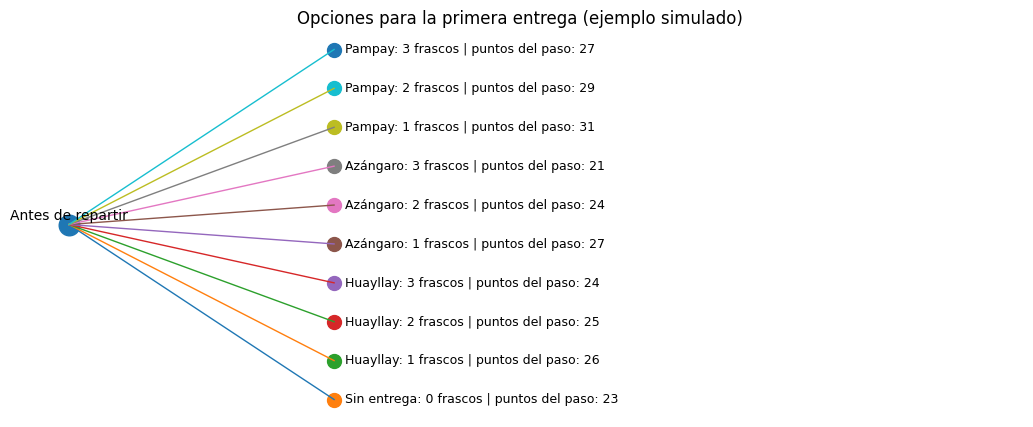

In [3]:
import matplotlib.pyplot as plt

primer_nivel = opciones(inicio)
plt.figure(figsize=(13, 5))
plt.scatter([0], [0], s=220)
plt.text(0, 0.12, "Antes de repartir", ha="center")
for i, (accion, estado, costo) in enumerate(primer_nivel):
    y = i - (len(primer_nivel) - 1) / 2
    plt.plot([0, 1], [0, y], linewidth=1)
    plt.scatter([1], [y], s=100)
    plt.text(1.04, y, f"{accion[0]}: {accion[1]} frascos | puntos del paso: {costo}", va="center", fontsize=9)
plt.xlim(-0.2, 3.6)
plt.axis("off")
plt.title("Opciones para la primera entrega (ejemplo simulado)")
plt.show()

**¿Qué nos muestra este dibujo?** Desde el inicio se puede elegir no entregar o enviar uno, dos o tres frascos a alguno de los destinos. Una misma cantidad puede costar distinto porque **el traslado y la prioridad cambian según el establecimiento**. «Costo del paso» incluye también lo que queda pendiente después de esa decisión; no es solo el precio de viajar.

## 6. DFS — búsqueda en profundidad
Usa **pila LIFO** como en el laboratorio. Entrega el primer plan completo encontrado; no necesariamente el de costo mínimo.

In [4]:
def dfs():
    pila = [(inicio, [])]
    visitados = []
    while pila:
        estado, plan = pila.pop()
        if estado in visitados:
            continue
        visitados.append(estado)
        if objetivo(estado):
            return plan, len(visitados)
        for accion, siguiente, costo in reversed(opciones(estado)):
            pila.append((siguiente, plan + [accion]))

plan_dfs, nodos_dfs = dfs()
print("DFS:", plan_dfs, "| Costo:", evaluar(plan_dfs)[0], "| Nodos:", nodos_dfs)

DFS: [('Sin entrega', 0), ('Sin entrega', 0), ('Sin entrega', 0), ('Sin entrega', 0)] | Costo: 184 | Nodos: 5


## 7. BFS — búsqueda en anchura
Usa **cola FIFO** como en el laboratorio. Todas las soluciones completas tienen cuatro decisiones; BFS no minimiza nuestro costo ponderado.

In [5]:
def bfs():
    cola = [(inicio, [])]
    visitados = [inicio]
    nodos = 0
    while cola:
        estado, plan = cola.pop(0)  # Primero en entrar, primero en salir.
        nodos += 1
        if objetivo(estado):
            return plan, nodos
        for accion, siguiente, costo in opciones(estado):
            if siguiente not in visitados:
                visitados.append(siguiente)
                cola.append((siguiente, plan + [accion]))

plan_bfs, nodos_bfs = bfs()
print("BFS:", plan_bfs, "| Costo:", evaluar(plan_bfs)[0], "| Nodos:", nodos_bfs)

BFS: [('Sin entrega', 0), ('Sin entrega', 0), ('Sin entrega', 0), ('Sin entrega', 0)] | Costo: 184 | Nodos: 137


## 8. BF — búsqueda exhaustiva
**BF (Brute Force) ≠ BFS.** Probaremos **todos los planes completos factibles**, y nos quedaremos con el de costo mínimo. Sirve para verificar A*.

In [6]:
def brute_force():
    pila = [(inicio, [])]
    mejor_plan = None
    mejor_costo = float("inf")
    completos = 0
    while pila:
        estado, plan = pila.pop()
        if objetivo(estado):
            completos += 1
            costo = evaluar(plan)[0]
            if costo < mejor_costo:
                mejor_costo = costo
                mejor_plan = plan
        else:
            for accion, siguiente, paso in opciones(estado):
                pila.append((siguiente, plan + [accion]))
    return mejor_plan, mejor_costo, completos

plan_bf, costo_bf, completos = brute_force()
print("BF:", plan_bf, "| Costo:", costo_bf, "| Planes completos:", completos)

BF: [('Azángaro', 3), ('Pampay', 3), ('Azángaro', 1), ('Huayllay', 2)] | Costo: 70 | Planes completos: 4993


## 9. Hill Climbing — mejorar una propuesta
Empezamos con cuatro oportunidades **sin entrega**. Luego cambiamos una sola decisión y comprobamos si el costo baja. Repetimos mientras haya una mejora: eso es buscar un **vecino mejor**, como en clase.

Puede detenerse sin encontrar el costo mínimo de todos los planes.

In [7]:
def vecinos(plan):
    resultado = []
    for turno in range(turnos):
        estado = inicio
        for accion_anterior in plan[:turno]:
            for posible, siguiente, paso in opciones(estado):
                if accion_anterior == posible:
                    estado = siguiente
                    break
        for accion, siguiente, paso in opciones(estado):
            candidato = plan.copy()
            candidato[turno] = accion
            if candidato != plan and evaluar(candidato) is not None:
                resultado.append(candidato)
    return resultado

def hill_climbing():
    plan = [("Sin entrega", 0)] * turnos
    intentos = 0
    while True:
        costo_actual = evaluar(plan)[0]
        mejor_plan = plan
        mejor_costo = costo_actual
        for candidato in vecinos(plan):
            intentos += 1
            costo = evaluar(candidato)[0]
            if costo < mejor_costo:
                mejor_plan = candidato
                mejor_costo = costo
        if mejor_costo >= costo_actual:
            return plan, costo_actual, intentos
        plan = mejor_plan

plan_hill, costo_hill, evaluados_hill = hill_climbing()
print("Hill Climbing:", plan_hill, "| Costo:", costo_hill, "| Vecinos evaluados:", evaluados_hill)

Hill Climbing: [('Azángaro', 3), ('Pampay', 3), ('Huayllay', 3), ('Sin entrega', 0)] | Costo: 73 | Vecinos evaluados: 102


## 10. A* — costo recorrido + estimación
Usamos la misma fórmula vista en clase:

**f(n) = g(n) + h(n)**

- **g(n):** costo realmente acumulado por las oportunidades ya decididas.
- **h(n):** estimación **mínima** de lo que falta: calcula cuántos frascos forzosamente quedarán pendientes aun si aprovechamos todas las próximas entregas. Usa el menor peso de prioridad para no exagerar. **No inventa costos de viajes futuros**: los deja en cero en la estimación.
- **f(n):** A* examina primero la opción con menor suma.

Ejemplo: si quedan cinco frascos pendientes, solo podemos repartir tres, la prioridad mínima es uno y al final se penaliza cuatro por frasco, entonces al menos dos frascos faltarán y la parte final estimada será `2 × 1 × 4 = 8` puntos. Otros costos futuros solo podrán aumentar el total.

Cuando ya completamos las cuatro oportunidades, `h(n)` incluye la penalización final **exacta**. Esto permite contrastar el costo mínimo de A* con Brute Force.

In [8]:
def heuristica(estado):
    turno, disponible, pendientes = estado
    peso_minimo = min(prioridad.values())
    if objetivo(estado):
        return penal_final * pendientes_ponderados(pendientes)

    # En el caso más favorable, cada turno futuro puede repartir hasta 'capacidad'.
    # Ignorar traslados futuros hace que la estimación no sobreestime.
    h = 0
    restantes = turnos - turno
    for paso in range(1, restantes + 1):
        max_entregables = min(disponible, paso * capacidad)
        faltante_minimo = max(0, sum(pendientes) - max_entregables)
        h += peso_minimo * faltante_minimo
    h += penal_final * peso_minimo * max(
        0, sum(pendientes) - min(disponible, restantes * capacidad)
    )
    return h

def a_estrella():
    abiertos = [(heuristica(inicio), 0, inicio, [])]  # f, g, estado, plan
    mejores = {inicio: 0}
    nodos = 0
    while abiertos:
        indice = 0
        for i in range(1, len(abiertos)):
            if abiertos[i][0] < abiertos[indice][0]:
                indice = i
        f, g, estado, plan = abiertos.pop(indice)
        if g != mejores[estado]:
            continue
        nodos += 1
        if objetivo(estado):
            return plan, g + penal_final * pendientes_ponderados(estado[2]), nodos
        for accion, siguiente, paso in opciones(estado):
            nuevo_g = g + paso
            if siguiente not in mejores or nuevo_g < mejores[siguiente]:
                mejores[siguiente] = nuevo_g
                nuevo_f = nuevo_g + heuristica(siguiente)
                abiertos.append((nuevo_f, nuevo_g, siguiente, plan + [accion]))

plan_astar, costo_astar, nodos_astar = a_estrella()
print("A*:", plan_astar, "| Costo:", costo_astar, "| Nodos:", nodos_astar)


A*: [('Azángaro', 3), ('Pampay', 3), ('Azángaro', 1), ('Huayllay', 2)] | Costo: 70 | Nodos: 55


## 11. Comparación de resultados: ¿qué encontró cada búsqueda?
Todos resuelven **el mismo escenario** con costos de traslado y prioridad simulados. Además del costo total, compararemos el orden de entregas, frascos pendientes en cada establecimiento y tiempo aproximado de ejecución.

**No son la misma medida:** DFS/BFS/A* cuentan estados explorados; BF cuenta planes completos y Hill Climbing cuenta vecinos evaluados. Los tiempos son orientativos y pueden cambiar al repetir la ejecución.

Si dos algoritmos llegan al mismo costo, es un resultado válido: no cambiaremos el código para obligarlos a diferir.

COMPARACIÓN (costos y datos SIMULADOS)

 DFS | Costo: 184 | Despachos: 0 | Trabajo: (5, 'estados')
 Orden: [('Sin entrega', 0), ('Sin entrega', 0), ('Sin entrega', 0), ('Sin entrega', 0)]
 Pendientes: {'Huayllay': 5, 'Azángaro': 4, 'Pampay': 3}

 BFS | Costo: 184 | Despachos: 0 | Trabajo: (137, 'estados')
 Orden: [('Sin entrega', 0), ('Sin entrega', 0), ('Sin entrega', 0), ('Sin entrega', 0)]
 Pendientes: {'Huayllay': 5, 'Azángaro': 4, 'Pampay': 3}

 BF | Costo: 70 | Despachos: 4 | Trabajo: (4993, 'planes completos')
 Orden: [('Azángaro', 3), ('Pampay', 3), ('Azángaro', 1), ('Huayllay', 2)]
 Pendientes: {'Huayllay': 3, 'Azángaro': 0, 'Pampay': 0}

 Hill Climbing | Costo: 73 | Despachos: 3 | Trabajo: (102, 'vecinos')
 Orden: [('Azángaro', 3), ('Pampay', 3), ('Huayllay', 3), ('Sin entrega', 0)]
 Pendientes: {'Huayllay': 2, 'Azángaro': 1, 'Pampay': 0}

 A* | Costo: 70 | Despachos: 4 | Trabajo: (55, 'estados')
 Orden: [('Azángaro', 3), ('Pampay', 3), ('Azángaro', 1), ('Huayllay', 2)]
 Pend


Tiempo aproximado (ms; cambia según la ejecución):
DFS : 0.04 ms
BFS : 2.39 ms
BF : 102.65 ms
Hill Climbing : 4.44 ms
A* : 0.75 ms


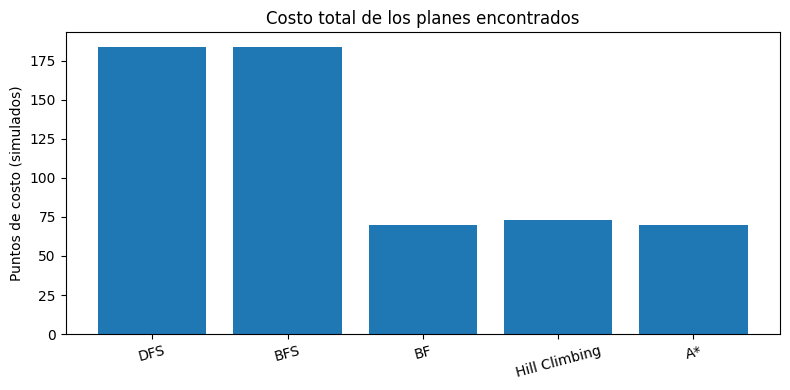

In [9]:
import time

planes = {
    "DFS": plan_dfs,
    "BFS": plan_bfs,
    "BF": plan_bf,
    "Hill Climbing": plan_hill,
    "A*": plan_astar
}
trabajo = {
    "DFS": (nodos_dfs, "estados"),
    "BFS": (nodos_bfs, "estados"),
    "BF": (completos, "planes completos"),
    "Hill Climbing": (evaluados_hill, "vecinos"),
    "A*": (nodos_astar, "estados")
}

print("COMPARACIÓN (costos y datos SIMULADOS)")
for nombre, plan in planes.items():
    costo, final = evaluar(plan)
    despachos = sum(1 for destino, cantidad in plan if cantidad > 0)
    pendientes_por_centro = dict(zip(nombres, final[2]))
    print("\n", nombre, "| Costo:", costo,
          "| Despachos:", despachos,
          "| Trabajo:", trabajo[nombre])
    print(" Orden:", plan)
    print(" Pendientes:", pendientes_por_centro)

assert costo_bf == costo_astar, "BF y A* deben coincidir en costo mínimo"
for plan in planes.values():
    assert evaluar(plan) is not None, "Plan inválido"
print("\nComprobaciones superadas: planes permitidos y BF = A*.")

# Tiempo orientativo: las cinco funciones se vuelven a ejecutar de la misma forma.
funciones = {"DFS": dfs, "BFS": bfs, "BF": brute_force,
             "Hill Climbing": hill_climbing, "A*": a_estrella}
tiempos = {}
for nombre, funcion in funciones.items():
    inicio_tiempo = time.perf_counter()
    funcion()
    tiempos[nombre] = (time.perf_counter() - inicio_tiempo) * 1000
print("\nTiempo aproximado (ms; cambia según la ejecución):")
for nombre, ms in tiempos.items():
    print(nombre, ":", round(ms, 2), "ms")

plt.figure(figsize=(8, 4))
plt.bar(list(planes), [evaluar(p)[0] for p in planes.values()])
plt.ylabel("Puntos de costo (simulados)")
plt.title("Costo total de los planes encontrados")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**¿Qué nos muestra este gráfico?** Cada barra indica cuánto cuesta el plan completo de un algoritmo, **incluyendo entrega, traslado, necesidades pendientes y prioridad**. Una barra más baja significa menos puntos **dentro de la simulación**, no un menor gasto real en soles. La tabla de arriba también muestra **a quién se entregó**, cuántos frascos faltan en cada destino y cuántas alternativas se revisaron.

## 12. Plan elegido: ¿a quién se entrega primero?
Mostramos el plan que encontró A*. En cada oportunidad veremos destino, frascos enviados, **distancia y costo de traslado simulados**, stock y frascos pendientes.

Las cuatro oportunidades, las cantidades y las distancias son parte de un ejercicio: **no son órdenes ni rutas reales de la DIRESA**.

PLAN DE COSTO MÍNIMO (SIMULACIÓN)
Paso | Destino | Frascos | Km sim. | Costo traslado | Stock | Pendientes
1 | Azángaro | 3 | 5 | 5 | 6 | 9
2 | Pampay | 3 | 8 | 8 | 3 | 6
3 | Azángaro | 1 | 5 | 5 | 2 | 5
4 | Huayllay | 2 | 2 | 2 | 0 | 3


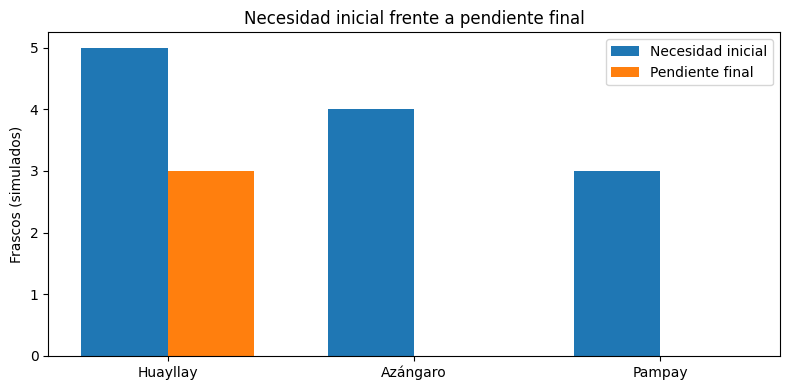

In [10]:
estado = inicio
print("PLAN DE COSTO MÍNIMO (SIMULACIÓN)")
print("Paso | Destino | Frascos | Km sim. | Costo traslado | Stock | Pendientes")
for numero, accion in enumerate(plan_astar, 1):
    for posible, siguiente, paso in opciones(estado):
        if accion == posible:
            estado = siguiente
            break
    destino, cantidad = accion
    km = distancia[destino] if cantidad > 0 else 0
    viaje = costo_traslado[destino] if cantidad > 0 else 0
    print(numero, "|", destino, "|", cantidad, "|", km,
          "|", viaje, "|", estado[1], "|", sum(estado[2]))

import matplotlib.pyplot as plt
ancho = 0.35
posiciones = list(range(len(nombres)))
plt.figure(figsize=(8, 4))
plt.bar([p - ancho/2 for p in posiciones], list(demanda.values()),
        width=ancho, label="Necesidad inicial")
plt.bar([p + ancho/2 for p in posiciones], list(estado[2]),
        width=ancho, label="Pendiente final")
plt.xticks(posiciones, nombres)
plt.ylabel("Frascos (simulados)")
plt.title("Necesidad inicial frente a pendiente final")
plt.legend()
plt.tight_layout()
plt.show()


**¿Qué nos muestra este gráfico?** Cada establecimiento tiene dos barras: los frascos que necesitaba al empezar y los que todavía le faltan al terminar el plan de A*. **La diferencia entre ambas es lo que recibió.** Ahora, además de cuántos frascos recibe cada uno, el costo considera que hay destinos más caros y necesidades con distinta prioridad. Como se solicitan 12 frascos y hay 9 disponibles, **al menos 3 quedarán pendientes**.

**¿Qué aprendimos?** DFS profundiza y BFS revisa por niveles; los dos buscan primero una programación permitida. BF revisa todos los planes completos de este escenario pequeño. Hill Climbing mejora poco a poco una propuesta. A* combina costo acumulado y una estimación mínima de lo que queda por atender.

**Qué cambió:** mantuvimos el código de clase y las reglas básicas, pero ahora el mismo envío puede costar distinto por traslado, y dejar pendiente un destino de mayor prioridad añade más puntos. Si varios algoritmos coinciden, comparamos también el orden y el trabajo realizado.

**Límite:** todas las cantidades, prioridades y distancias del experimento son simuladas. Para planificar entregas reales harían falta inventarios, demandas, rutas y costos verificados.

## 13. Referencias
1. DIRESA Ayacucho (2025). *DIRESA garantiza el abastecimiento de suero fisiológico...* https://www.gob.pe/institucion/regionayacucho-diresa/noticias/1152815-diresa-garantiza-el-abastecimiento-de-suero-fisiologico-en-todos-los-establecimientos-de-salud-de-la-region
2. MINSA (2026). *Resolución Ministerial N.° 193-2026-MINSA*. https://www.gob.pe/institucion/minsa/normas-legales/7852638-193-2026-minsa
3. DIGEMID (2026). *Modernización SISMED 2.6*. https://www.digemid.minsa.gob.pe/webDigemid/notas/2026/ministerio-de-salud-moderniza-sistema-para-fortalecer-suministro-de-medicamentos-en-establecimientos-de-salud-y-evitar-su-desabastecimiento/
4. SUSALUD. *RENIPRESS*, catálogo público para contrastar vigencia de establecimientos: https://www.datosabiertos.gob.pe/

**Nota metodológica:** los códigos se conservan de la versión inicial del ejercicio basada en listados institucionales; no se afirma aquí haber descargado, emparejado ni comprobado un extracto RENIPRESS actualizado.